# Assignment 8: NLP and Text Classification

## Business Problem

Food delivery companies receive many customer comments from apps, surveys, social media, and support channels.
Reading and sorting all comments by hand takes a lot of time.
This notebook builds a simple NLP model that reads a customer comment and predicts its topic, such as delivery, pricing, packaging, food quality, app experience, or customer service.
This helps the company organize feedback faster and send the right comments to the right team.

## Libraries


In [1]:
# Basic libraries
import os
import re
import string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Stemming tool
from nltk.stem import PorterStemmer

# Display settings
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42


Matplotlib is building the font cache; this may take a moment.


## Task 1: Load and Inspect the Dataset

In [2]:
# Load the dataset
# This notebook is inside Week8/notebook and the CSV file is inside Week8/data.
# The code below also works if Jupyter is launched from the Week8 folder or the project root.

DATA_FILE_NAME = 'food_delivery_feedback_topic_dataset.csv'

candidate_paths = [
    Path('../data') / DATA_FILE_NAME,              # when running from Week8/notebook
    Path('data') / DATA_FILE_NAME,                 # when running from Week8
    Path('Week8/data') / DATA_FILE_NAME,           # when running from the repository root
    Path.cwd().parent / 'data' / DATA_FILE_NAME,
    Path.cwd() / 'data' / DATA_FILE_NAME,
    Path.cwd() / 'Week8' / 'data' / DATA_FILE_NAME
]

# Also allow small filename variations, such as food_delivery_feedback_topic_dataset(1).csv
candidate_paths.extend(Path.cwd().glob('**/food_delivery_feedback_topic_dataset*.csv'))

DATA_PATH = None
for path in candidate_paths:
    path = Path(path).resolve()
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    searched_paths = '\n'.join(str(Path(path)) for path in candidate_paths[:6])
    raise FileNotFoundError(
        'Could not find the dataset CSV file.\n'
        'Expected layout: Week8/data/food_delivery_feedback_topic_dataset.csv\n\n'
        'Main searched paths:\n' + searched_paths
    )

# Set project folder based on the data folder.
# If DATA_PATH is Week8/data/file.csv, PROJECT_DIR becomes Week8.
PROJECT_DIR = DATA_PATH.parent.parent
OUTPUT_DIR = PROJECT_DIR / 'outputs'
FIGURES_DIR = PROJECT_DIR / 'figures'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

# Show dataset shape and first few rows
print('Dataset path:', DATA_PATH)
print('Project folder:', PROJECT_DIR)
print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

df.head()


Dataset path: /mnt/data/test_layout/Week8/data/food_delivery_feedback_topic_dataset.csv
Project folder: /mnt/data/test_layout/Week8
Dataset shape: (120, 9)

Column names:
['CommentID', 'CommentDate', 'Platform', 'City', 'MealType', 'CustomerSegment', 'CustomerComment', 'FeedbackTopic', 'EngagementScore']


,CommentID,CommentDate,Platform,City,MealType,CustomerSegment,CustomerComment,FeedbackTopic,EngagementScore
0,COM-001,2026-03-06,TikTok,Ajax,Breakfast,Weekly User,"Prices are reasonable when there is a lunch promotion, but normal fees are high.",Pricing,12
1,COM-002,2026-03-09,X/Twitter,Oshawa,Salad,Student,Support kept sending copied messages and did not read my complaint about the missing Salad.,Customer_Service,19
2,COM-003,2026-03-12,Facebook,London,Breakfast,Office Worker,"The drink holder was weak, so the coffee spilled before it reached my office.",Packaging,26
3,COM-004,2026-03-15,Google Review,Whitby,Indian Food,Family,No one replied to my email for three days. This is not acceptable customer care.,Customer_Service,33
4,COM-005,2026-03-18,Instagram,London,Pasta,First-Time User,The service fee and delivery fee made my Pasta order too expensive in London. #FreshBite,Pricing,40


In [3]:
# Check data types
print('Data types:')
print(df.dtypes)


Data types:
CommentID          object
CommentDate        object
Platform           object
City               object
MealType           object
CustomerSegment    object
CustomerComment    object
FeedbackTopic      object
EngagementScore     int64
dtype: object


In [4]:
# Check missing values
missing_values = df.isnull().sum()
print('Missing values:')
print(missing_values)


Missing values:
CommentID          0
CommentDate        0
Platform           0
City               0
MealType           0
CustomerSegment    0
CustomerComment    0
FeedbackTopic      0
EngagementScore    0
dtype: int64


In [5]:
# Check duplicate records
duplicate_count = df.duplicated().sum()
print('Number of duplicate records:', duplicate_count)


Number of duplicate records: 0


Target variable distribution:
FeedbackTopic
Pricing             20
Customer_Service    20
Packaging           20
Food_Quality        20
Delivery            20
App_Experience      20
Name: count, dtype: int64


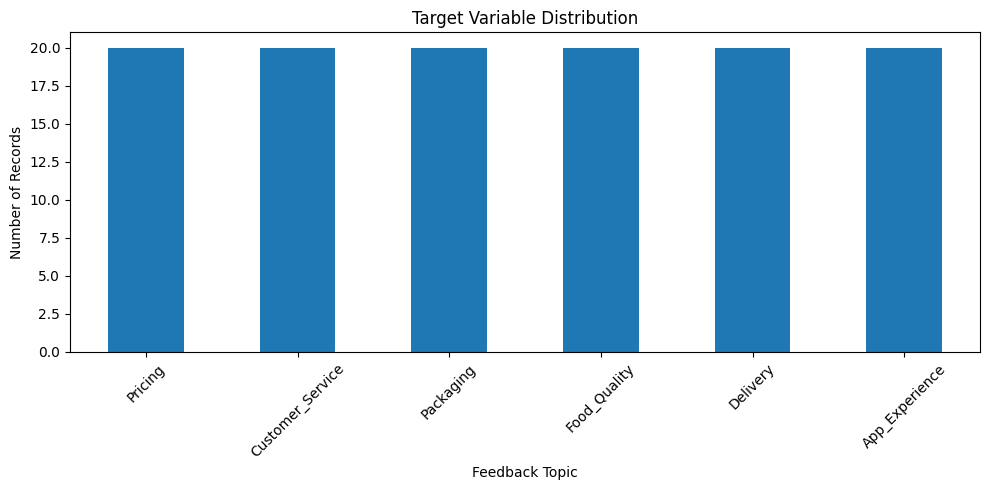

In [6]:
# Target variable distribution
target_column = 'FeedbackTopic'

target_distribution = df[target_column].value_counts()
print('Target variable distribution:')
print(target_distribution)

target_distribution.plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Feedback Topic')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_variable_distribution.png', dpi=150)
plt.show()


### Task 1 Explanation

The dataset has 120 records and 9 columns.
The main text column is CustomerComment, which contains the customer feedback. The target variable is FeedbackTopic, which is the topic the model tries to predict.
The model reads a customer comment and predicts its topic, such as delivery, pricing, packaging, food quality, app experience, or customer service.
The dataset is balanced because each topic has the same number of records. This helps the model learn each topic more fairly.

## Task 2: Text Preprocessing

In [7]:
# Choose the main text column
text_column = 'CustomerComment'

# Basic English stopwords for this assignment
stopwords = {
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'to', 'of', 'in', 'on', 'for', 'with', 'at',
    'by', 'from', 'up', 'about', 'into', 'over', 'after', 'before', 'between', 'through',
    'during', 'is', 'am', 'are', 'was', 'were', 'be', 'been', 'being', 'this', 'that',
    'these', 'those', 'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'she', 'it',
    'they', 'them', 'their', 'as', 'not', 'no', 'so', 'too', 'very', 'can', 'could',
    'should', 'would', 'will', 'just', 'than', 'then', 'there', 'here', 'when', 'where',
    'what', 'who', 'how', 'why', 'did', 'do', 'does', 'had', 'has', 'have', 'also'
}

stemmer = PorterStemmer()

def preprocess_text(text):
    """Clean and tokenize text using basic NLP preprocessing."""
    # Convert text to string and lowercase
    text = str(text).lower()
    
    # Remove URLs and hashtags symbol, but keep the word after hashtag
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = text.replace('#', ' ')
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize by splitting on spaces
    tokens = text.split()
    
    # Remove stopwords and short tokens
    tokens = [word for word in tokens if word not in stopwords and len(word) > 1]
    
    # Apply stemming
    tokens = [stemmer.stem(word) for word in tokens]
    
    # Join tokens back into cleaned text
    return ' '.join(tokens)

# Create cleaned text column
df['CleanedComment'] = df[text_column].apply(preprocess_text)

# Compare original and cleaned text
comparison_df = df[[text_column, 'CleanedComment']].head(10)
comparison_df


,CustomerComment,CleanedComment
0,"Prices are reasonable when there is a lunch promotion, but normal fees are high.",price reason lunch promot normal fee high
1,Support kept sending copied messages and did not read my complaint about the missing Salad.,support kept send copi messag read complaint miss salad
2,"The drink holder was weak, so the coffee spilled before it reached my office.",drink holder weak coffe spill reach offic
3,No one replied to my email for three days. This is not acceptable customer care.,one repli email three day accept custom care
4,The service fee and delivery fee made my Pasta order too expensive in London. #FreshBite,servic fee deliveri fee made pasta order expens london freshbit
5,The Coffee tasted fresh and warm. FreshBite should keep this restaurant on the app! #FreshBite,coffe tast fresh warm freshbit keep restaur app freshbit
6,"The drink holder was weak, so the coffee spilled before it reached my office.",drink holder weak coffe spill reach offic
7,"The salad was okay, but the chicken was dry and needed more sauce.",salad okay chicken dri need more sauc
8,"FRESHBITE DELIVERED MY PIZZA ORDER TO TORONTO 25 MINUTES LATE, AND THE DRIVER COULD NOT FIND THE BUILDING. #FRESHBITE",freshbit deliv pizza order toronto minut late driver find build freshbit
9,The FreshBite app froze when I tried to apply the SAVE10 coupon on Monday.,freshbit app froze tri appli save coupon monday


### Task 2 Explanation

Preprocessing cleans the customer comments before training the model.

Raw text can include capital letters, punctuation, stopwords, and different word forms. These can make the text harder for the model to use.
I changed the text to lowercase, removed punctuation and stopwords, split the text into words, and applied stemming.
This helps the model focus on the most important words for predicting the feedback topic.

## Task 3: Exploratory Text Analysis

In [8]:
# Combine all cleaned comments into one list of words
all_words = ' '.join(df['CleanedComment']).split()

# Count word frequency
word_counts = Counter(all_words)
common_words = word_counts.most_common(20)

# Convert to DataFrame
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
word_freq_df


,Word,Frequency
0,freshbit,53
1,app,25
2,price,20
3,order,20
4,fee,15
5,deliveri,15
6,driver,15
7,food,15
8,toronto,11
9,lunch,10


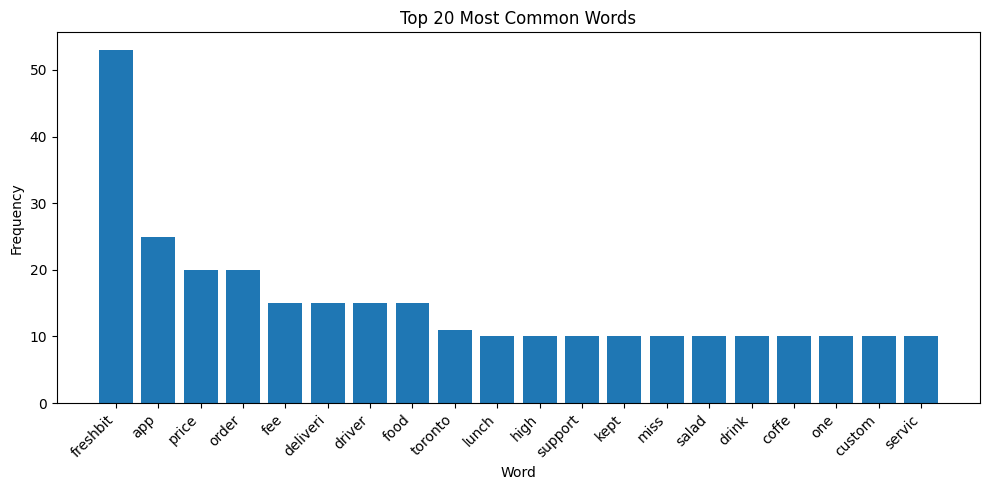

In [9]:
# Save word frequency table
word_freq_df.to_csv(OUTPUT_DIR / 'word_frequency.csv', index=False)

# Plot top 20 words
plt.bar(word_freq_df['Word'], word_freq_df['Frequency'])
plt.title('Top 20 Most Common Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_20_common_words.png', dpi=150)
plt.show()


### Task 3 Interpretation

The most common words show the main topics in the customer comments.Words like delivery, service, food, price, app, support, and FreshBite appear often.

This tells us that customers are mostly talking about delivery speed, food quality, customer support, pricing, and app experience.

## Task 4: POS Tagging and Named Entity Recognition

In [10]:
# Select three example records from different topics
example_records = df.groupby('FeedbackTopic').head(1).head(3).copy()
example_records[[text_column, 'FeedbackTopic']]


,CustomerComment,FeedbackTopic
0,"Prices are reasonable when there is a lunch promotion, but normal fees are high.",Pricing
1,Support kept sending copied messages and did not read my complaint about the missing Salad.,Customer_Service
2,"The drink holder was weak, so the coffee spilled before it reached my office.",Packaging


In [11]:
# Simple rule-based POS tagging and NER for assignment demonstration
known_cities = set(df['City'].dropna().astype(str).unique())
known_brands = {'FreshBite'}
known_meals = set(df['MealType'].dropna().astype(str).unique())
known_names = {'Maria'}
known_platforms = set(df['Platform'].dropna().astype(str).unique())

adjective_words = {
    'fast', 'slow', 'cold', 'hot', 'fresh', 'warm', 'weak', 'clean', 'reasonable',
    'high', 'fair', 'simple', 'professional', 'missing', 'late', 'expensive',
    'dry', 'oily', 'polite', 'great', 'acceptable', 'new', 'latest'
}

verb_words = {
    'arrived', 'called', 'handled', 'replied', 'answered', 'refunded', 'showed',
    'loads', 'worked', 'helped', 'tasted', 'spilled', 'leaked', 'solved', 'keep',
    'finish', 'ordering', 'reached', 'separated', 'sending', 'read'
}

noun_words = {
    'delivery', 'driver', 'order', 'food', 'support', 'service', 'price', 'receipt',
    'checkout', 'drink', 'holder', 'coffee', 'office', 'soup', 'bag', 'napkins',
    'restaurant', 'app', 'filter', 'update', 'email', 'complaint', 'salad', 'chicken',
    'sauce', 'discount', 'code', 'student', 'budget', 'sushi', 'box', 'items', 'meal'
}

def simple_tokenize_original(text):
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d{1,2}:\d{2}\s?[AP]M|\d+", str(text))

def simple_pos_tag(text):
    tokens = simple_tokenize_original(text)
    tagged_tokens = []
    for token in tokens:
        lower = token.lower()
        if lower in adjective_words:
            tag = 'ADJ'
        elif lower in verb_words or lower.endswith('ed') or lower.endswith('ing'):
            tag = 'VERB'
        elif lower in noun_words:
            tag = 'NOUN'
        elif token in known_cities or token in known_brands or token in known_meals or token in known_names:
            tag = 'PROPN'
        elif re.match(r'^\d', token):
            tag = 'NUM'
        else:
            tag = 'OTHER'
        tagged_tokens.append((token, tag))
    return tagged_tokens

def simple_ner(text):
    entities = []
    for city in known_cities:
        if city in str(text):
            entities.append((city, 'LOCATION'))
    for brand in known_brands:
        if brand in str(text):
            entities.append((brand, 'ORGANIZATION'))
    for meal in known_meals:
        if meal in str(text):
            entities.append((meal, 'PRODUCT_OR_MEAL'))
    for name in known_names:
        if name in str(text):
            entities.append((name, 'PERSON'))
    # Detect simple time patterns such as 12:30 PM
    for match in re.findall(r'\b\d{1,2}:\d{2}\s?[AP]M\b', str(text)):
        entities.append((match, 'TIME'))
    return entities

# Apply POS tagging and NER to examples
pos_ner_results = []
for index, row in example_records.iterrows():
    comment = row[text_column]
    pos_ner_results.append({
        'FeedbackTopic': row['FeedbackTopic'],
        'CustomerComment': comment,
        'POS_Tags': simple_pos_tag(comment),
        'Named_Entities': simple_ner(comment)
    })

pos_ner_df = pd.DataFrame(pos_ner_results)
pos_ner_df


,FeedbackTopic,CustomerComment,POS_Tags,Named_Entities
0,Pricing,"Prices are reasonable when there is a lunch promotion, but normal fees are high.","[(Prices, OTHER), (are, OTHER), (reasonable, ADJ), (when, OTHER), (there, OTHER), (is, OTHER), (a, OTHER), (lunch, O...",[]
1,Customer_Service,Support kept sending copied messages and did not read my complaint about the missing Salad.,"[(Support, NOUN), (kept, OTHER), (sending, VERB), (copied, VERB), (messages, OTHER), (and, OTHER), (did, OTHER), (no...","[(Salad, PRODUCT_OR_MEAL)]"
2,Packaging,"The drink holder was weak, so the coffee spilled before it reached my office.","[(The, OTHER), (drink, NOUN), (holder, NOUN), (was, OTHER), (weak, ADJ), (so, OTHER), (the, OTHER), (coffee, NOUN), ...",[]


In [12]:
# Display the POS and NER results in a clearer way
for item in pos_ner_results:
    print('Topic:', item['FeedbackTopic'])
    print('Comment:', item['CustomerComment'])
    print('POS tags:', item['POS_Tags'])
    print('Named entities:', item['Named_Entities'])
    print('-' * 80)


Topic: Pricing
Comment: Prices are reasonable when there is a lunch promotion, but normal fees are high.
POS tags: [('Prices', 'OTHER'), ('are', 'OTHER'), ('reasonable', 'ADJ'), ('when', 'OTHER'), ('there', 'OTHER'), ('is', 'OTHER'), ('a', 'OTHER'), ('lunch', 'OTHER'), ('promotion', 'OTHER'), ('but', 'OTHER'), ('normal', 'OTHER'), ('fees', 'OTHER'), ('are', 'OTHER'), ('high', 'ADJ')]
Named entities: []
--------------------------------------------------------------------------------
Topic: Customer_Service
Comment: Support kept sending copied messages and did not read my complaint about the missing Salad.
POS tags: [('Support', 'NOUN'), ('kept', 'OTHER'), ('sending', 'VERB'), ('copied', 'VERB'), ('messages', 'OTHER'), ('and', 'OTHER'), ('did', 'OTHER'), ('not', 'OTHER'), ('read', 'VERB'), ('my', 'OTHER'), ('complaint', 'NOUN'), ('about', 'OTHER'), ('the', 'OTHER'), ('missing', 'ADJ'), ('Salad', 'NOUN')]
Named entities: [('Salad', 'PRODUCT_OR_MEAL')]
-------------------------------------

### Task 4 Explanation

POS tagging shows the role of each word. Nouns show the main topic, such as delivery, price, app, food, or support. Verbs show actions, such as arrived or refunded. Adjectives show opinions, such as fast, slow, cold, or expensive.
Named Entity Recognition finds important names, places, brands, dates, or times.
This helps the business understand what customers are discussing and which areas need attention.

## Task 5: Feature Extraction

In [13]:
# Define X and y
X_text = df['CleanedComment']
y = df['FeedbackTopic']

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(max_features=1000)
X_features = vectorizer.fit_transform(X_text)

print('TF-IDF feature matrix shape:', X_features.shape)
print('Number of TF-IDF features:', len(vectorizer.get_feature_names_out()))

# Show first 20 feature names
vectorizer.get_feature_names_out()[:20]


TF-IDF feature matrix shape: (120, 163)
Number of TF-IDF features: 163


array(['accept', 'address', 'ajax', 'amaz', 'ani', 'anoth', 'answer',
       'app', 'appl', 'appli', 'arriv', 'bag', 'better', 'bowl', 'box',
       'budget', 'build', 'call', 'care', 'chat'], dtype=object)

### Task 5 Explanation

Text must be changed into numbers because machine learning models use numbers to learn.
I used TF-IDF to convert each cleaned comment into numerical features. Each feature represents a word, and the value shows how important that word is in the comment.
This helps the model connect certain words with certain feedback topics.

## Task 6: Build a Text Classification Model

In [14]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])


Training set size: 96
Testing set size: 24


In [15]:
# Train a simple text classification model
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = model.predict(X_test)

# Create a comparison table
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
comparison['Correct'] = comparison['Actual'] == comparison['Predicted']
comparison.head(10)


,Actual,Predicted,Correct
0,Food_Quality,Food_Quality,True
1,Packaging,Packaging,True
2,Food_Quality,Food_Quality,True
3,Pricing,Pricing,True
4,Delivery,Delivery,True
5,App_Experience,App_Experience,True
6,Customer_Service,Customer_Service,True
7,App_Experience,App_Experience,True
8,Delivery,Delivery,True
9,Food_Quality,Food_Quality,True


### Task 6 Explanation

The model learns from customer comments and their topic labels.
The training data teaches the model. The testing data checks whether the model can classify new comments correctly.

## Task 7: Model Evaluation

In [16]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy, 4))


Accuracy: 1.0


In [17]:
# Create confusion matrix
labels = sorted(df['FeedbackTopic'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df


,App_Experience,Customer_Service,Delivery,Food_Quality,Packaging,Pricing
App_Experience,4,0,0,0,0,0
Customer_Service,0,4,0,0,0,0
Delivery,0,0,4,0,0,0
Food_Quality,0,0,0,4,0,0
Packaging,0,0,0,0,4,0
Pricing,0,0,0,0,0,4


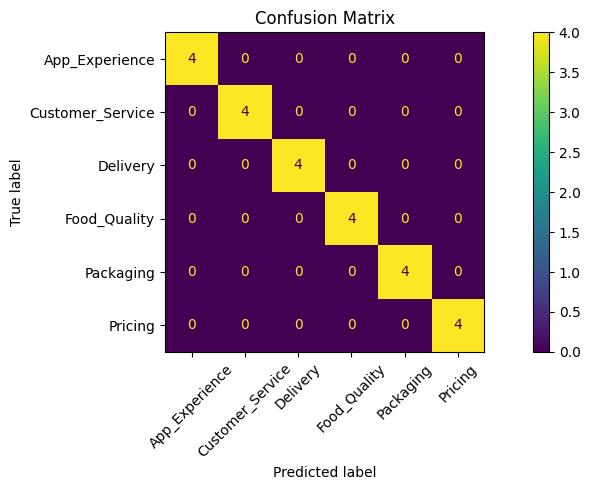

In [18]:
# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=150)
plt.show()


In [19]:
# Classification report
report = classification_report(y_test, y_pred, output_dict=False)
print(report)


                  precision    recall  f1-score   support

  App_Experience       1.00      1.00      1.00         4
Customer_Service       1.00      1.00      1.00         4
        Delivery       1.00      1.00      1.00         4
    Food_Quality       1.00      1.00      1.00         4
       Packaging       1.00      1.00      1.00         4
         Pricing       1.00      1.00      1.00         4

        accuracy                           1.00        24
       macro avg       1.00      1.00      1.00        24
    weighted avg       1.00      1.00      1.00        24



In [20]:
# Save prediction comparison and cleaned dataset
comparison.to_csv(OUTPUT_DIR / 'test_prediction_comparison.csv', index=False)
df.to_csv(OUTPUT_DIR / 'cleaned_food_delivery_feedback_dataset.csv', index=False)
cm_df.to_csv(OUTPUT_DIR / 'confusion_matrix.csv')


### Task 7 Business Explanation

Accuracy shows how many test comments the model classified correctly.
The confusion matrix shows where the model is right and where it is wrong. If the model sends a comment to the wrong topic, the business may send it to the wrong team.
The classification report shows precision, recall, and F1-score for each topic. This helps us see whether the model performs well across all feedback categories.

## Task 8: Business Interpretation

In [21]:
# Top words by topic for business interpretation
for topic in sorted(df['FeedbackTopic'].unique()):
    topic_words = ' '.join(df.loc[df['FeedbackTopic'] == topic, 'CleanedComment']).split()
    topic_common = Counter(topic_words).most_common(8)
    print(topic, ':', topic_common)


App_Experience : [('app', 20), ('freshbit', 8), ('toronto', 8), ('froze', 5), ('tri', 5), ('appli', 5), ('save', 5), ('coupon', 5)]
Customer_Service : [('freshbit', 13), ('support', 10), ('miss', 10), ('custom', 10), ('kept', 5), ('send', 5), ('copi', 5), ('messag', 5)]
Delivery : [('deliv', 10), ('order', 10), ('driver', 10), ('deliveri', 10), ('freshbit', 8), ('pizza', 5), ('minut', 5), ('late', 5)]
Food_Quality : [('meal', 10), ('freshbit', 8), ('coffe', 5), ('tast', 5), ('fresh', 5), ('warm', 5), ('keep', 5), ('restaur', 5)]
Packaging : [('freshbit', 8), ('drink', 5), ('holder', 5), ('weak', 5), ('coffe', 5), ('spill', 5), ('reach', 5), ('offic', 5)]
Pricing : [('price', 20), ('fee', 15), ('freshbit', 8), ('reason', 5), ('lunch', 5), ('promot', 5), ('normal', 5), ('high', 5)]


### Final Business Interpretation

This model predicts the topic of food delivery customer comments.
I used CustomerComment as the text column and FeedbackTopic as the target variable.
I cleaned the text by lowercasing, removing punctuation, removing stopwords, tokenizing, and applying stemming.
Then I used TF-IDF to turn the text into numbers and Logistic Regression to classify the comments.
The model performed well on the test data. A key business insight is that customers often talk about delivery, pricing, packaging, food quality, app experience, and customer service.

One limitation is that the dataset is small and has repeated sentence patterns. Before real business use, the company should test the model on more real customer comments.
